## Part 5 Train on signle image (neglict ci)

## import libraries

In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
from nerflab import (
    Intrinsics, Camera,
    CFG, pose_H, make_pose_cases, 
    viz_sigma_heatmap, viz_sigma_scatter,
)
from nerflab.viz.plot_cloud import plot_cloud_batch_with_camera
from nerflab.learning.utils import get_batch_rays, query_density_field
from nerflab.learning import stratified_samples_batch, cartesian_to_spherical
from nerflab.learning.forward_sigma import nerf_opacity


In [2]:
# gpu_check.py
import torch
import platform
import sys

print(f"PyTorch           : {torch.__version__}")
print(f"Python            : {platform.python_version()} ({sys.executable})")
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA toolkit ver. : {torch.version.cuda}")
    print(f"CuDNN ver.        : {torch.backends.cudnn.version()}")
    print(f"GPU count         : {torch.cuda.device_count()}")
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        print(f"  · Device {idx}: {props.name} "
              f"({props.total_memory/1024**3:.1f} GB, "
              f"Compute {props.major}.{props.minor})")
else:
    print("→  No CUDA GPU detected by PyTorch.")


PyTorch           : 2.7.1+cu128
Python            : 3.10.12 (/home/elyamani/Main/programming/nerf-lab/.venv/bin/python)
CUDA available    : False
→  No CUDA GPU detected by PyTorch.


/home/elyamani/Main/programming/nerf-lab/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# build preset dictionary
cases = make_pose_cases(axis_dist=3)

# pick a view (e.g., diagonal)
H_wc = pose_H(cases["+Z"])  
# H_wc = np.eye(4)
print(H_wc)

[[ 1.  0. -0.  0.]
 [-0.  1. -0.  0.]
 [ 0.  0.  1.  3.]
 [ 0.  0.  0.  1.]]


In [4]:
# --- sample rays -------------------------------------------------------------
# O_w, D_w = cam.get_rays(frame="world")
O_w, D_w = get_batch_rays(H_wc)
# O_w = torch.from_numpy(O_w)
# D_w = torch.from_numpy(D_w)
t, delta, pts = stratified_samples_batch(O_w, D_w)
print("points shape:", pts.shape)


points shape: torch.Size([4096, 20, 3])


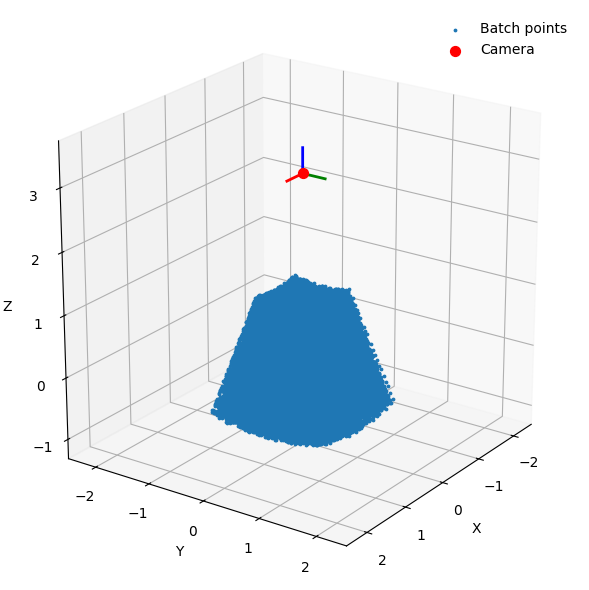

In [5]:
plot_cloud_batch_with_camera(pts, H_wc)

In [6]:

from nerflab.viz import viz_cfg
viz_cfg.figsize = (9, 7)
viz_cfg.default_alpha = 0.5
sigma = query_density_field(pts)

Loading world from ../data/world.json ...


In [7]:
print(sigma.shape)
print(sigma.min(), sigma.max())

torch.Size([4096, 20])
tensor(0.) tensor(inf)


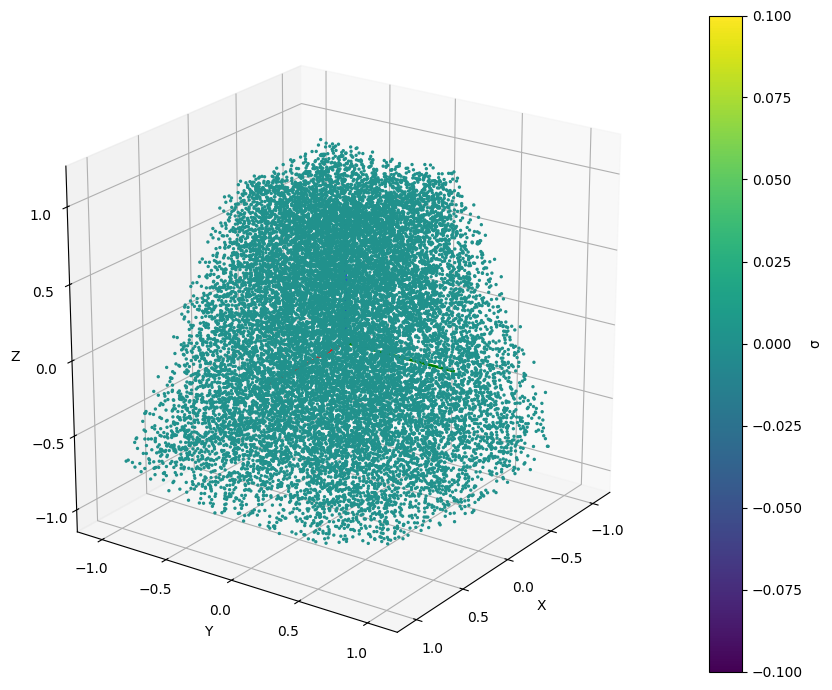

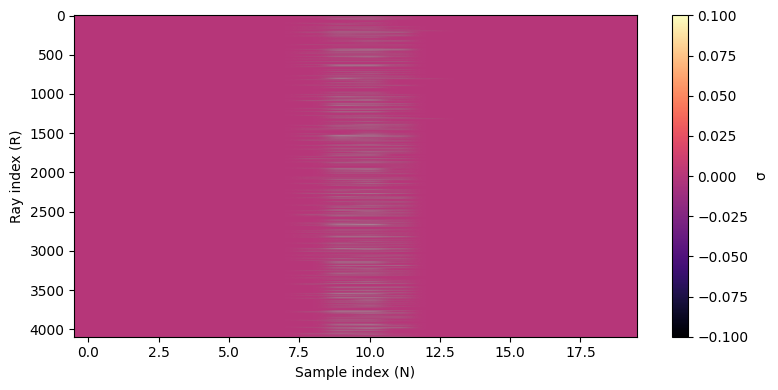

In [8]:
viz_sigma_scatter(pts.numpy(), sigma.numpy())
viz_sigma_heatmap(sigma)


In [9]:
T, w, C = nerf_opacity(sigma, delta)


In [10]:
print(np.unique(C))
print(C.min(), C.max())

[0. 1.]
tensor(0.) tensor(1.)


In [11]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Literal, Optional
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

h, w = int(CFG.intrinsics.height), int(CFG.intrinsics.width)
im = np.round(C.reshape(h,  w), 2)

# im is 0/1 array
cmap = ListedColormap(['black', 'white'])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

plt.imshow(im, cmap=cmap, norm=norm, interpolation='nearest')
plt.axis('off')
plt.show()


RuntimeError: shape '[480, 640]' is invalid for input of size 4096

In [ ]:
print(CFG.intrinsics)

IntrinsicsCfg(width=640, height=480, fx=1194.2562584220407, fy=895.6921938165306)


In [ ]:
print(t.shape)
print(sigma.shape)
indcies, x = np.where(sigma !=0)

(307200, 20)
(307200, 20)


In [ ]:
print(f"# rays hit {indcies.shape}")
print(np.unique(x))

# rays hit (97706,)
[ 8  9 10 11 12]


177531


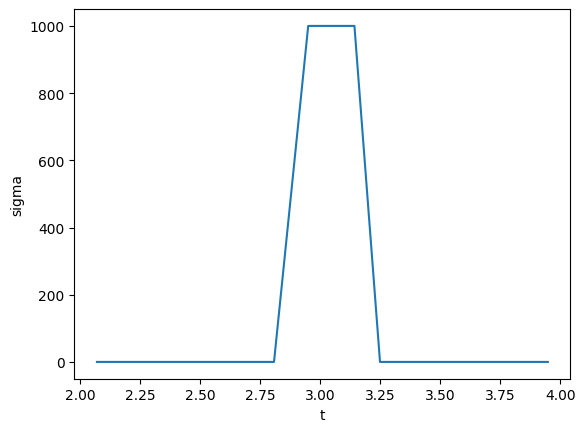

In [ ]:
idx = np.random.choice(indcies)
print(idx)
plt.plot(t[idx], np.clip(sigma[idx], 0, 1000))
plt.xlabel("t")
plt.ylabel("sigma")
plt.show()

In [ ]:
# Debug once

bad_sigma = ~np.isfinite(sigma)
bad_delta = ~np.isfinite(delta)
print("bad sigma:", bad_sigma.any(), "bad delta:", bad_delta.any())


bad sigma: False bad delta: False
